In [1]:
# 📦 Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB



In [23]:
#  Load the data
import pandas as pd
movies = pd.read_csv("movies_metadata.csv", low_memory=False, nrows=10000)
ratings = pd.read_csv("ratings_small.csv")
display(movies.head())
display(ratings.head())


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


10000


'Maximum popularity: 140.950236'

'Average runtime: 103.59655793476085'

103.6


In [24]:
#stastics of movie recommendation
print(movies.shape[0])
max_popularity=movies['popularity'].max()
avg_runtime=movies['runtime'].mean() # Changed recommended_movies to movies
display(f"Maximum popularity: {max_popularity}")
display(f"Average runtime: {avg_runtime}")
print(round(avg_runtime,2))


10000


'Maximum popularity: 140.950236'

'Average runtime: 103.59655793476085'

103.6


In [6]:
#  Keep only useful columns and clean data
movies = movies[['id', 'title', 'overview', 'vote_average', 'popularity']]
movies = movies.dropna(subset=['title', 'overview'])

In [71]:
#  Create 'liked' column
ratings['liked'] = ratings['rating'].apply(lambda x: 1 if x >= 4 else 0)
print(ratings)

        userId  movieId  rating   timestamp  liked
0            1       31     2.5  1260759144      0
1            1     1029     3.0  1260759179      0
2            1     1061     3.0  1260759182      0
3            1     1129     2.0  1260759185      0
4            1     1172     4.0  1260759205      1
...        ...      ...     ...         ...    ...
99999      671     6268     2.5  1065579370      0
100000     671     6269     4.0  1065149201      1
100001     671     6365     4.0  1070940363      1
100002     671     6385     2.5  1070979663      0
100003     671     6565     3.5  1074784724      0

[100004 rows x 5 columns]


In [7]:

#  Create a simple recommendation system using overview
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies['overview'])
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()



In [74]:
# Function to get movie recommendations based on cosine similarity
def get_recommendations(title, cos_sim=cos_sim):
    if title not in indices:
        return pd.Series([]) # Return empty series if title not found
    idx = indices[title]
    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:31]  # Get the top 30 similar movies
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]




In [9]:

# Get recommendations for 'Toy Story'
Sorted_Similar_Movies = get_recommendations('Toy Story')

print('Top 30 Movies Suggested for you: \n')

i = 1

for movie in Sorted_Similar_Movies:
    if (i<31):
        print(i, '.', movie)
        i+=1




Top 30 Movies Suggested for you: 

1 . Toy Story 2
2 . The Champ
3 . Man on the Moon
4 . Rivers and Tides
5 . Class of 1984
6 . Heartbeeps
7 . Malice
8 . Condorman
9 . The First $20 Million Is Always the Hardest
10 . The Sunchaser
11 . For Love or Money
12 . Life Is Sweet
13 . Indecent Proposal
14 . White Men Can't Jump
15 . Losin' It
16 . What's Up, Tiger Lily?
17 . Bound for Glory
18 . Funny Farm
19 . I Shot Andy Warhol
20 . For Love or Country: The Arturo Sandoval Story
21 . Grass
22 . Child's Play 3
23 . Radio Days
24 . The Shawshank Redemption
25 . Rubin and Ed
26 . Totally Fucked Up
27 . Window to Paris
28 . Firestarter
29 . Hollywood Ending
30 . Smiles of a Summer Night


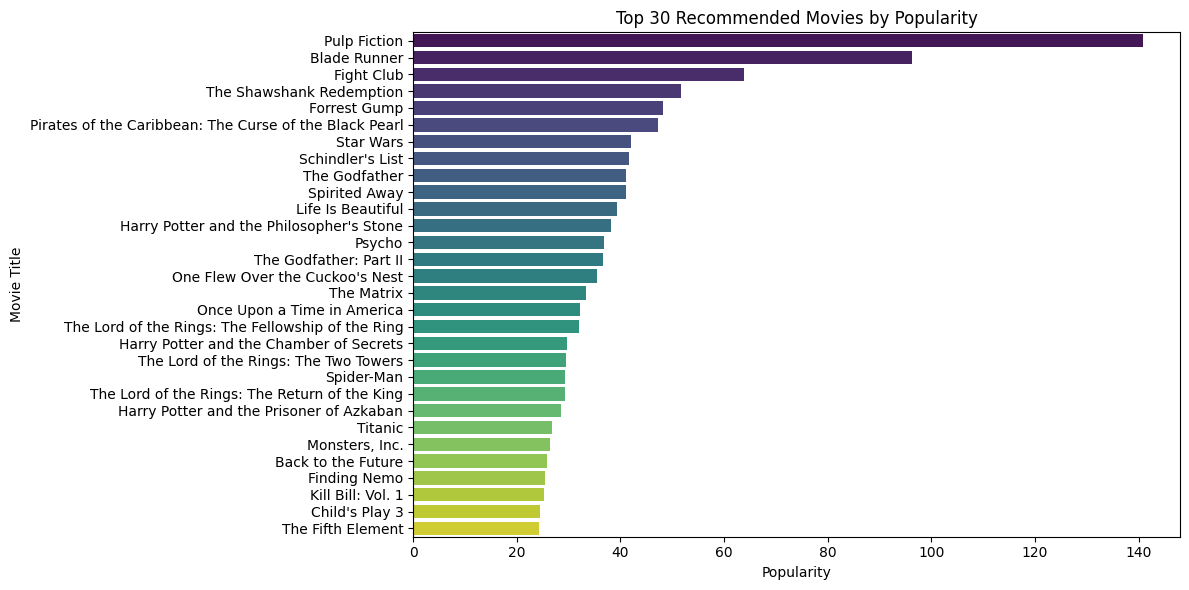

In [30]:
#visualizations [barplot]
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

top_movies = movies.sort_values('popularity', ascending=False).head(30)

sns.barplot(
    data=top_movies,x='popularity', y='title',hue='title',palette='viridis')

plt.title('Top 30 Recommended Movies by Popularity')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


/tmp/ipython-input-38-955130780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies[movies['original_language'].isin(top_langs)],


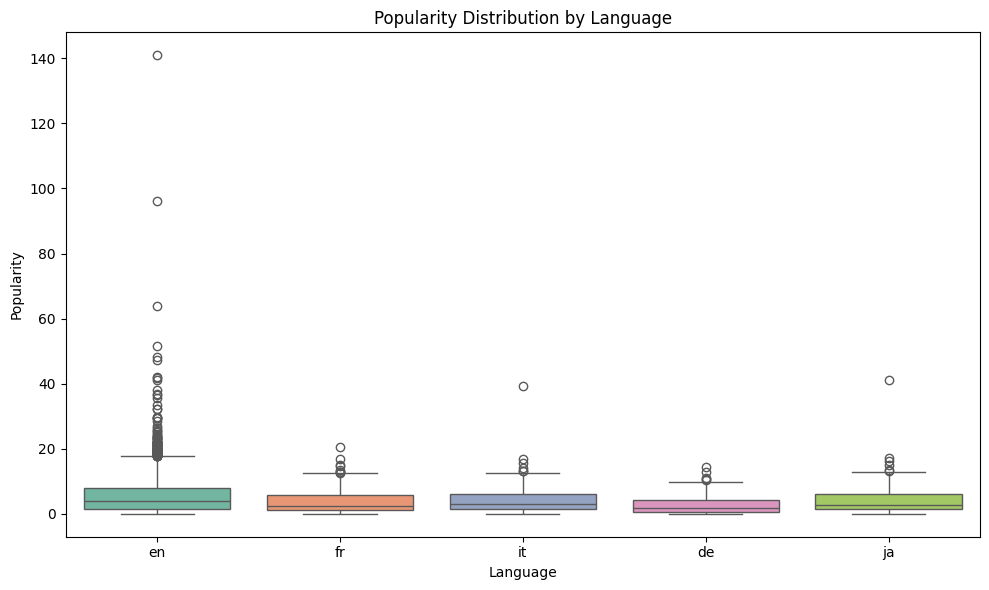

In [38]:
top_langs = movies['original_language'].value_counts().nlargest(5).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=movies[movies['original_language'].isin(top_langs)],
            x='original_language', y='popularity', palette='Set2')
plt.title('Popularity Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


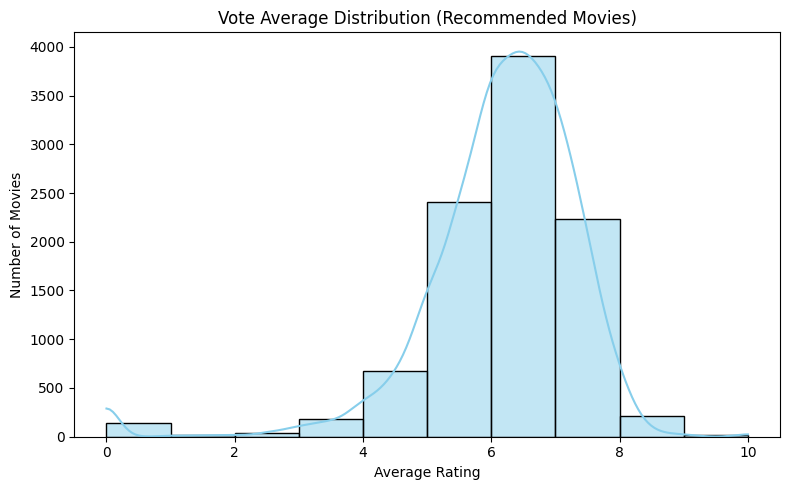

In [33]:
# 2️⃣ Histogram: Distribution of Vote Averages
plt.figure(figsize=(8, 5))
sns.histplot(data=movies, x='vote_average', bins=10, kde=True, color='skyblue')
plt.title('Vote Average Distribution (Recommended Movies)')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


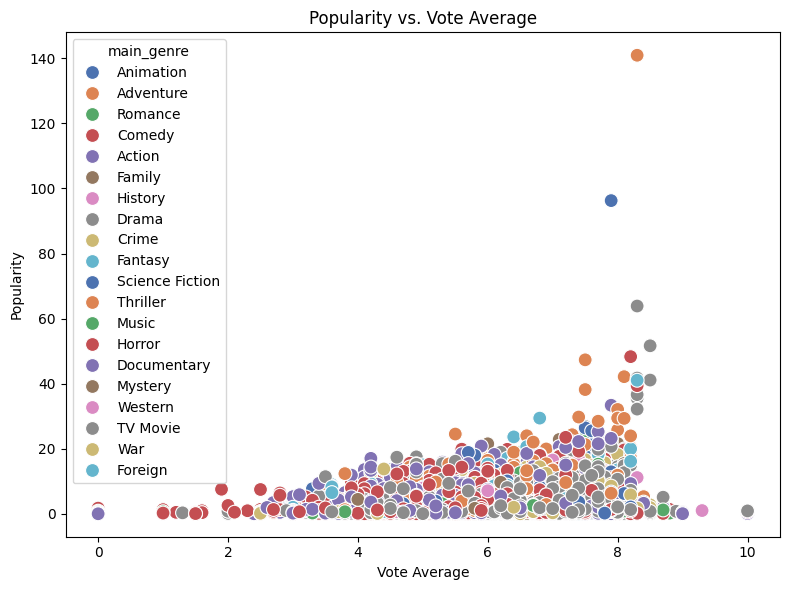

In [35]:
 # 5️⃣ Scatterplot: Popularity vs. Vote Average
plt.figure(figsize=(8, 6))
sns.scatterplot(data=movies, x='vote_average', y='popularity', hue='main_genre', palette='deep', s=100)
plt.title('Popularity vs. Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


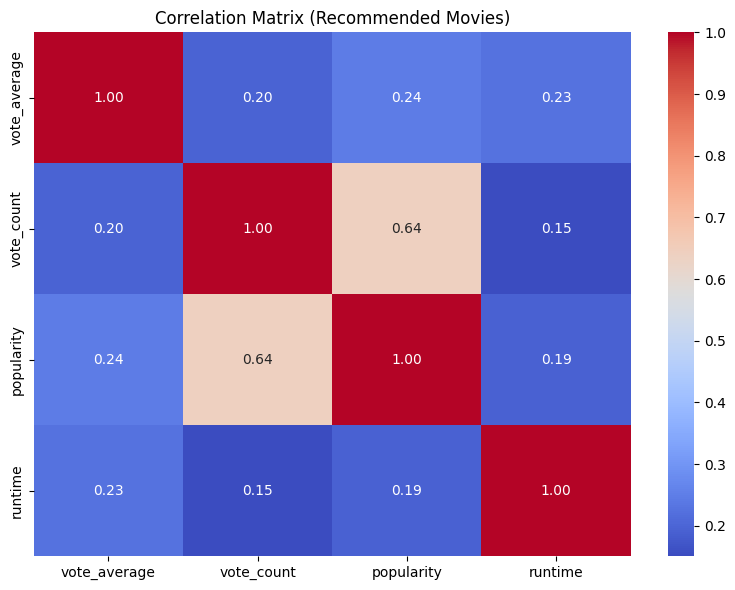

In [36]:
plt.figure(figsize=(8, 6))
corr = movies[['vote_average', 'vote_count', 'popularity', 'runtime']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Recommended Movies)')
plt.tight_layout()
plt.show()

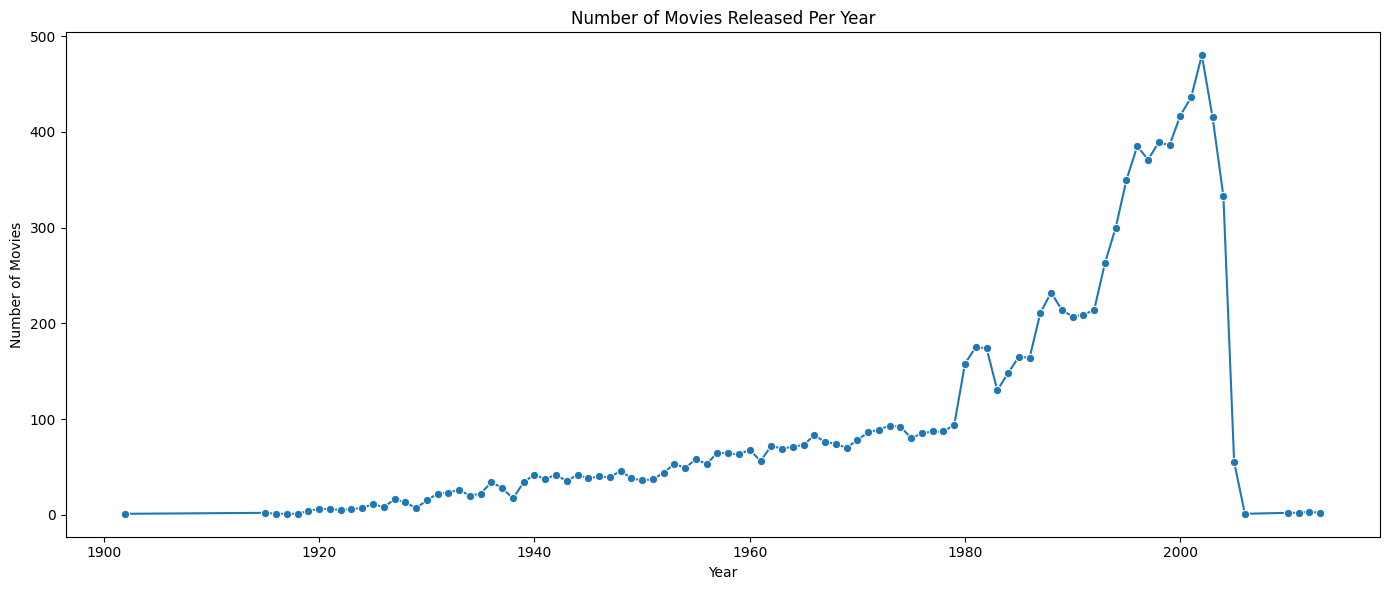

In [37]:
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
year_counts = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


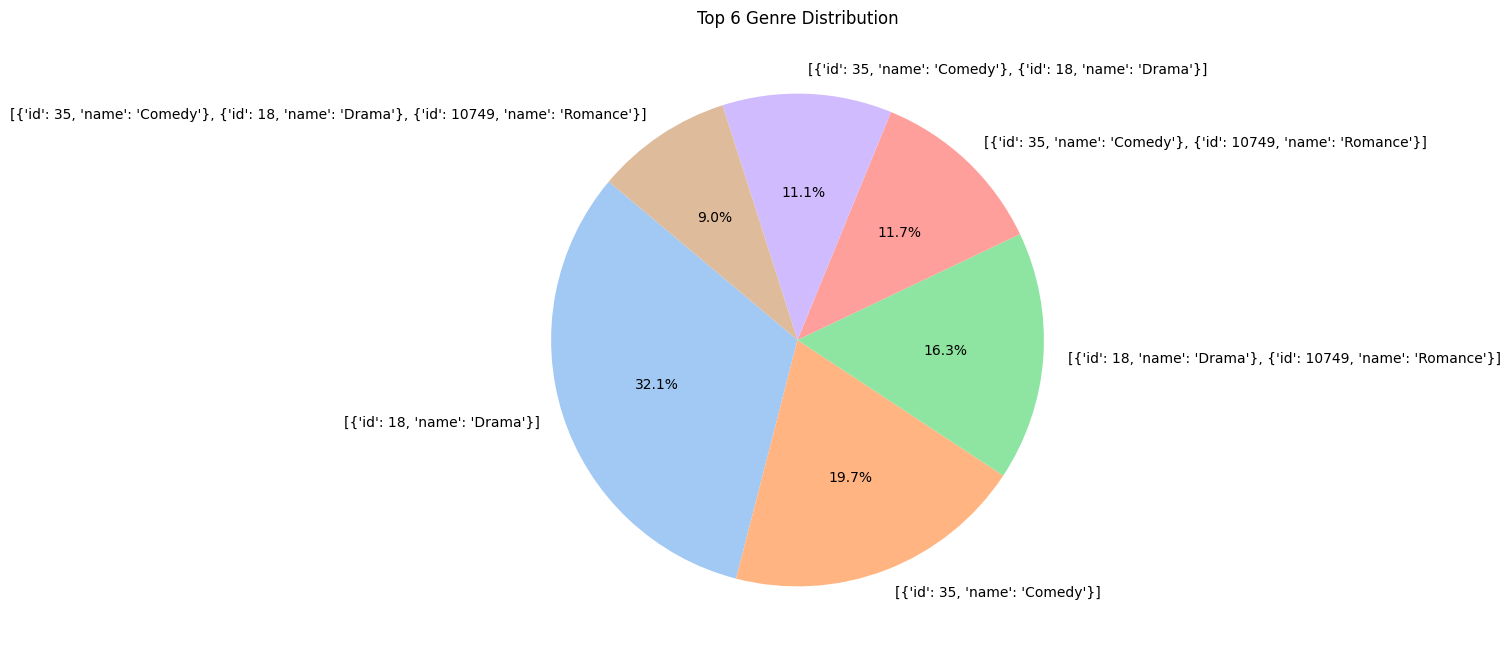

In [43]:
genre_counts = movies['genres'].value_counts().nlargest(6)
plt.figure(figsize=(8, 8))
plt.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140)
plt.title('Top 6 Genre Distribution')

plt.show()


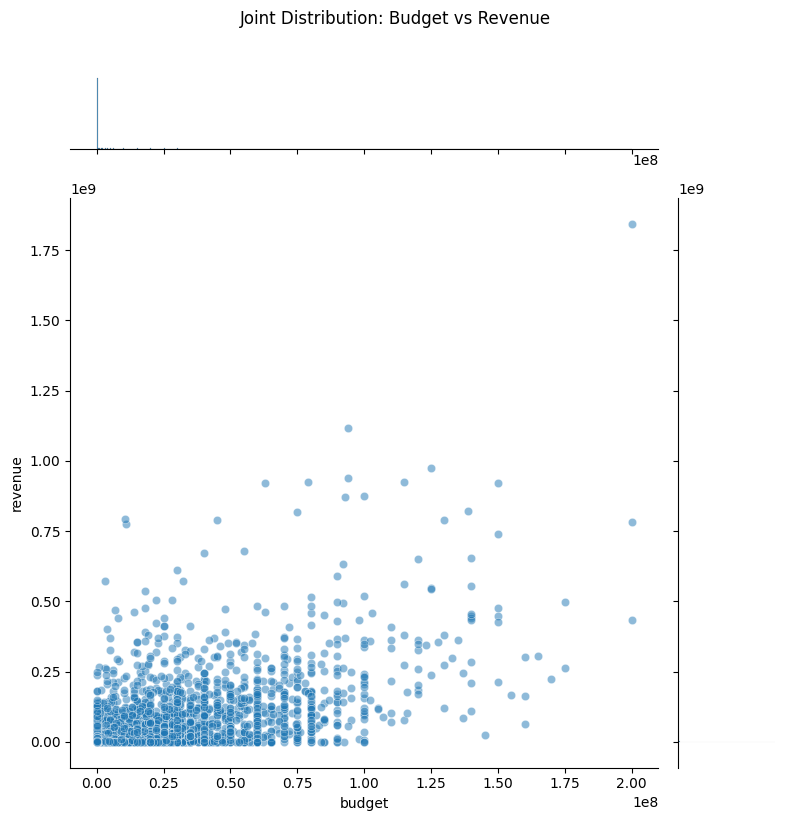

In [44]:
sns.jointplot(data=movies, x='budget', y='revenue', kind='scatter', alpha=0.5, height=8)
plt.suptitle('Joint Distribution: Budget vs Revenue', y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipython-input-45-4124775180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=movies, y='original_language', order=movies['original_language'].value_counts().index[:10], palette='Spectral')


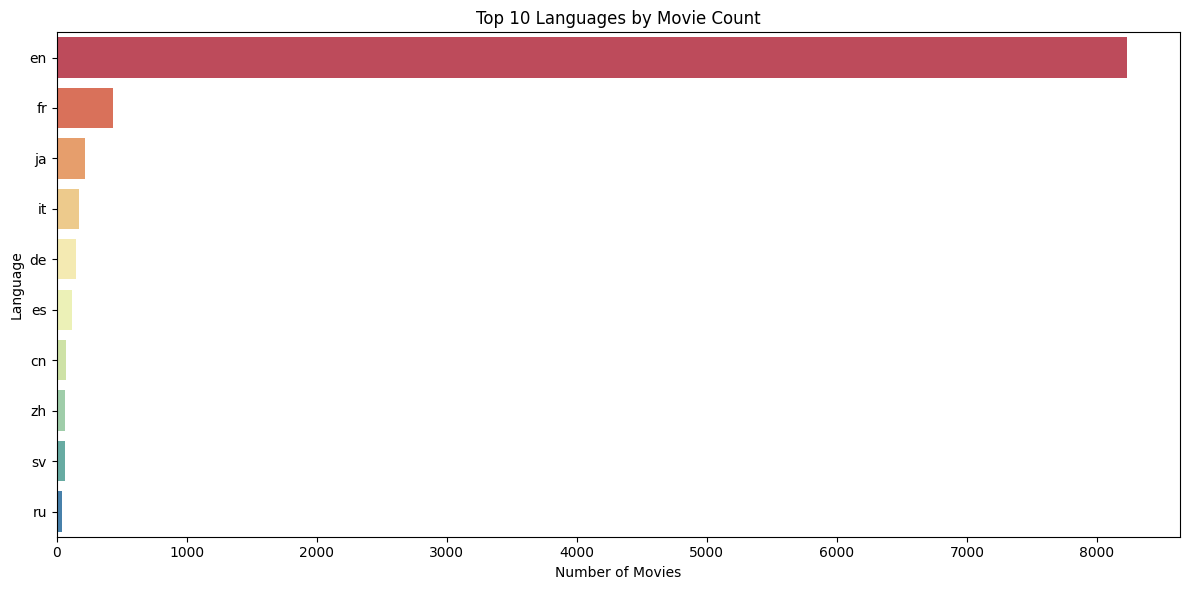

In [45]:
plt.figure(figsize=(12, 6))
sns.countplot(data=movies, y='original_language', order=movies['original_language'].value_counts().index[:10], palette='Spectral')
plt.title('Top 10 Languages by Movie Count')
plt.xlabel('Number of Movies')
plt.ylabel('Language')
plt.tight_layout()
plt.show()


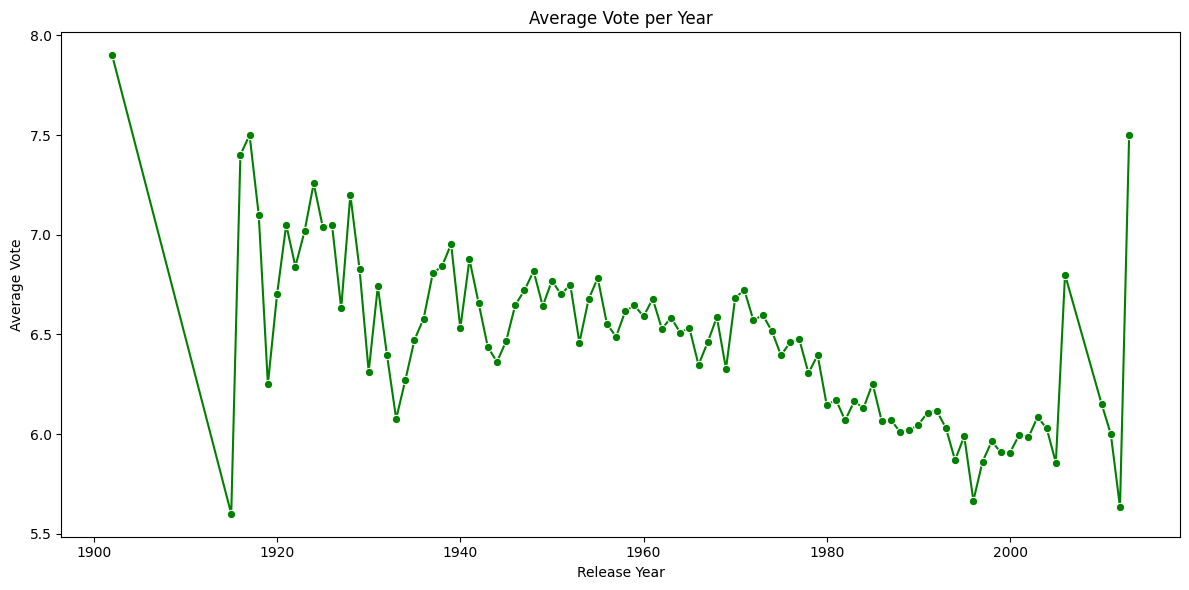

In [46]:
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
avg_vote_by_year = movies.groupby('release_year')['vote_average'].mean().dropna()

plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_vote_by_year.index, y=avg_vote_by_year.values, marker='o', color='green')
plt.title('Average Vote per Year')
plt.xlabel('Release Year')
plt.ylabel('Average Vote')
plt.tight_layout()
plt.show()


/tmp/ipython-input-47-3786912890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=movies[movies['original_language'].isin(top_langs)],


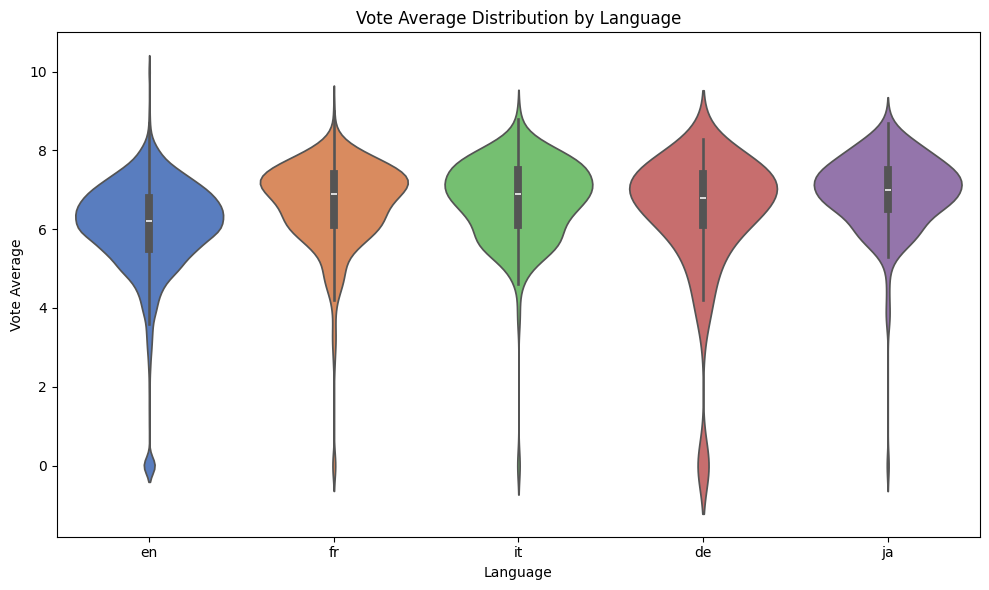

In [47]:
 #Violin Plot: Vote Average Distribution by Language
top_langs = movies['original_language'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.violinplot(data=movies[movies['original_language'].isin(top_langs)],
               x='original_language', y='vote_average', palette='muted')
plt.title('Vote Average Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Vote Average')
plt.tight_layout()
plt.show()

/tmp/ipython-input-54-3849906875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue, x='revenue', y='title', palette='Blues_d')


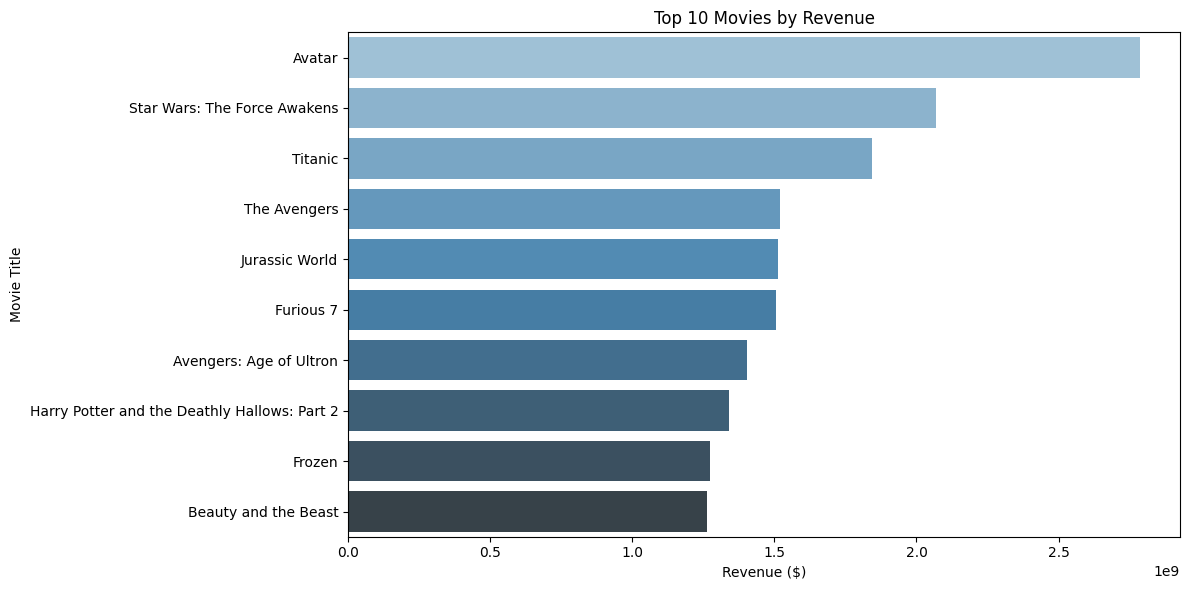

In [54]:
top_revenue = movies.sort_values(by='revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_revenue, x='revenue', y='title', palette='Blues_d')
plt.title('Top 10 Movies by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


/tmp/ipython-input-58-1170729971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=subset, x='original_language', y='vote_count', jitter=True, palette='pastel')


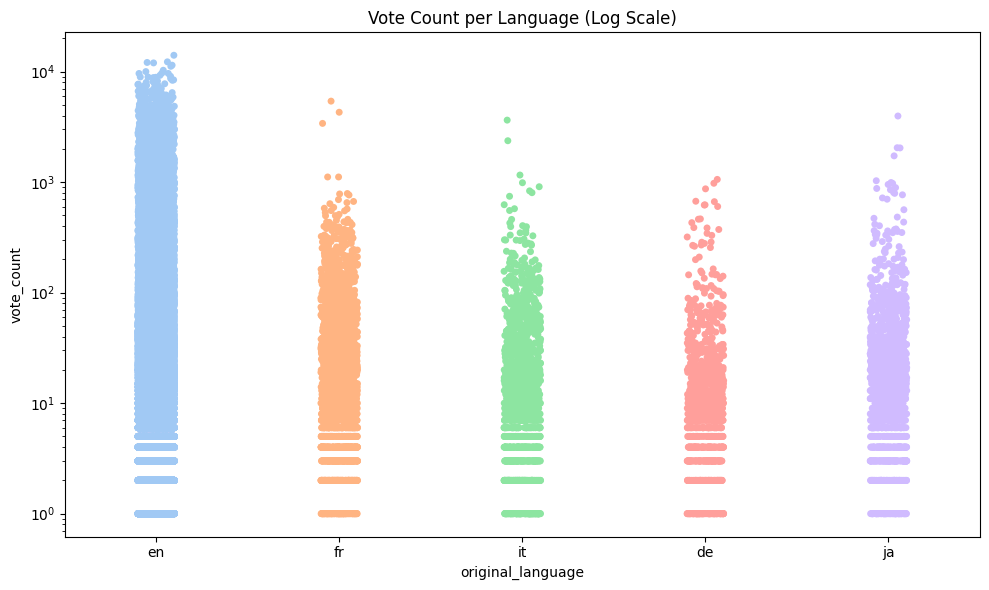

In [58]:
top_langs = movies['original_language'].value_counts().head(5).index
subset = movies[movies['original_language'].isin(top_langs)]

plt.figure(figsize=(10, 6))
sns.stripplot(data=subset, x='original_language', y='vote_count', jitter=True, palette='pastel')
plt.yscale('log')
plt.title("Vote Count per Language (Log Scale)")
plt.tight_layout()
plt.show()


In [64]:
#  Define X and y for classification models
X = merged[['userId', 'movieId']]
y = merged['liked']

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
print("📊 Decision Tree Accuracy:", dt_model.score(X_test, y_test))

📊 Decision Tree Accuracy: 0.5860742705570292


In [66]:
from sklearn.linear_model import LogisticRegression

#  Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
print("📊 Logistic Regression Acuracy:", log_model.score(X_test, y_test))

📊 Logistic Regression Acuracy: 0.5362068965517242


In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

#  KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
print("📊 KNN Accuracy:", knn_model.score(X_test, y_test))

# 🧠 KMeans clustering on numeric features
features = merged[['vote_average', 'popularity']]
kmeans = KMeans(n_clusters=5, random_state=0)
merged['cluster'] = kmeans.fit_predict(features)

📊 KNN Accuracy: 0.5858090185676392


In [12]:
#  PCA for 2D Visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())

# Only keep movies used in tfidf_matrix
movies = movies.reset_index(drop=True)  # Ensure matching index
reduced_data = pca.fit_transform(tfidf_matrix.toarray())  # No change here



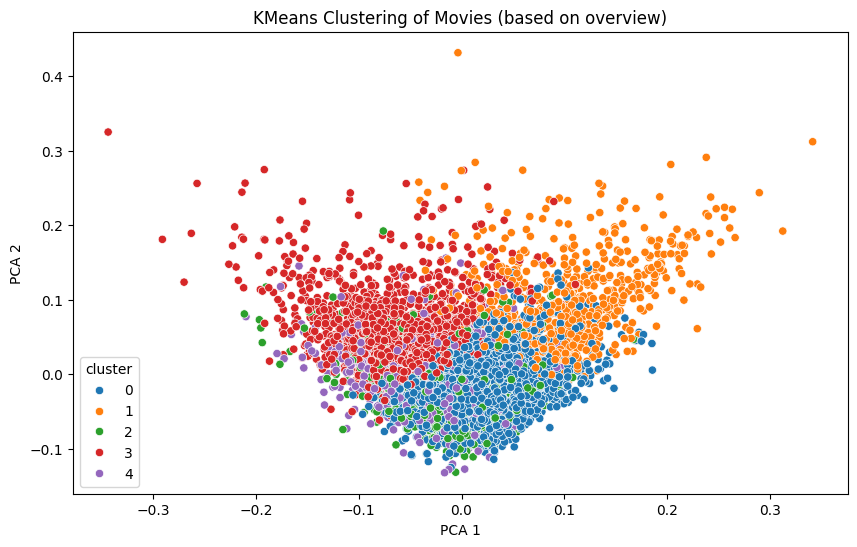

In [13]:
# Visualize KMeans clusters


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=reduced_data[:, 0],
    y=reduced_data[:, 1],
    hue=movies['cluster'],
    palette='tab10',
    legend='full'
)
plt.title("KMeans Clustering of Movies (based on overview)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()



In [14]:
# 🧾 Final Recommended Movies Print
print('\n🎬 Top 30 Recommended Movies similar to Toy Story:\n')
for i, movie in enumerate(Sorted_Similar_Movies[:30], start=1):
    print(f"{i}. {movie}")


🎬 Top 30 Recommended Movies similar to Toy Story:

1. Toy Story 2
2. The Champ
3. Man on the Moon
4. Rivers and Tides
5. Class of 1984
6. Heartbeeps
7. Malice
8. Condorman
9. The First $20 Million Is Always the Hardest
10. The Sunchaser
11. For Love or Money
12. Life Is Sweet
13. Indecent Proposal
14. White Men Can't Jump
15. Losin' It
16. What's Up, Tiger Lily?
17. Bound for Glory
18. Funny Farm
19. I Shot Andy Warhol
20. For Love or Country: The Arturo Sandoval Story
21. Grass
22. Child's Play 3
23. Radio Days
24. The Shawshank Redemption
25. Rubin and Ed
26. Totally Fucked Up
27. Window to Paris
28. Firestarter
29. Hollywood Ending
30. Smiles of a Summer Night


In [52]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving movies_metadata.csv to movies_metadata (1).csv
User uploaded file "movies_metadata (1).csv" with length 34445126 bytes


In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving ratings_small.csv to ratings_small.csv
User uploaded file "ratings_small.csv" with length 2438266 bytes
